NSE DATA SHAPE: (3674, 6)
RELIANCE DATA SHAPE: (2468, 6)


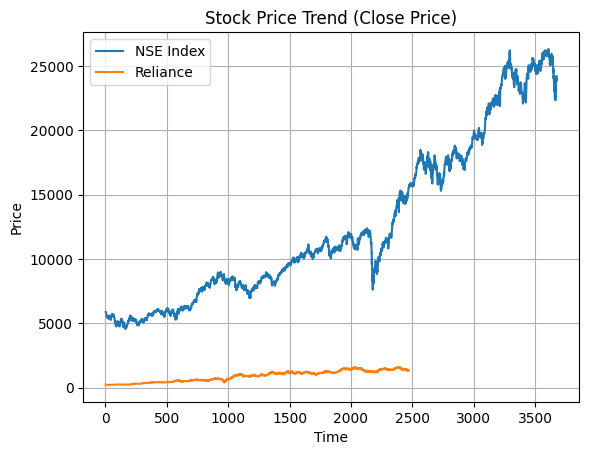

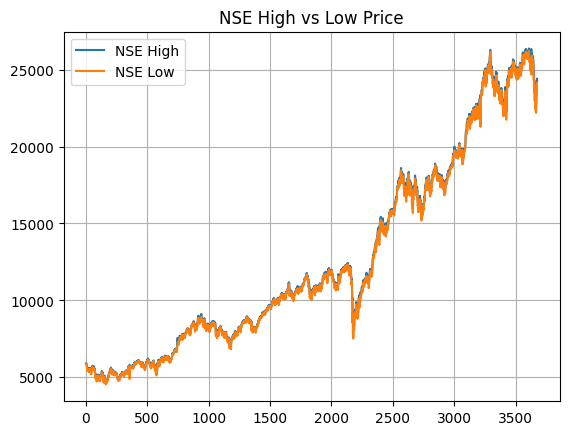

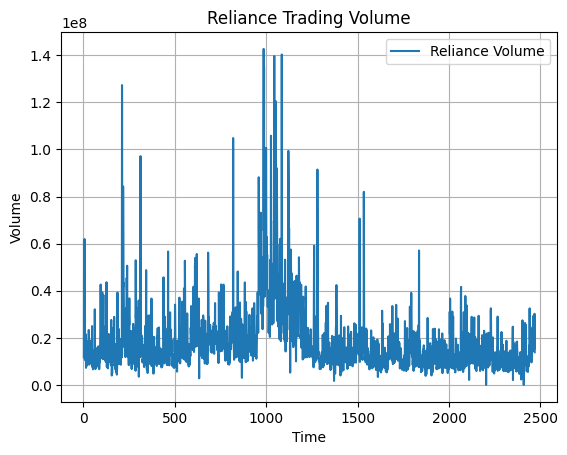

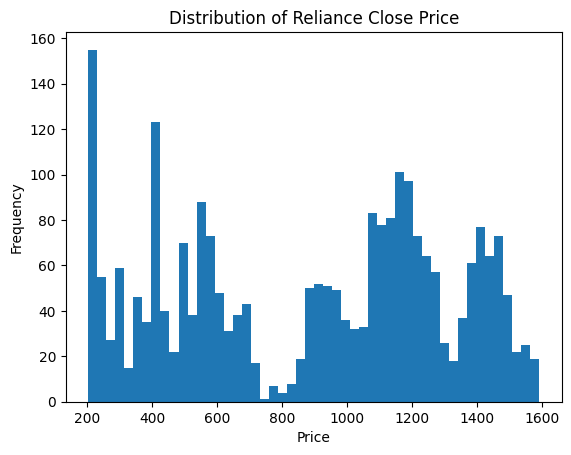

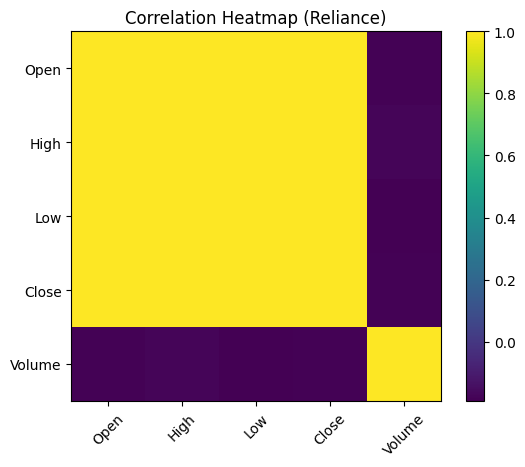

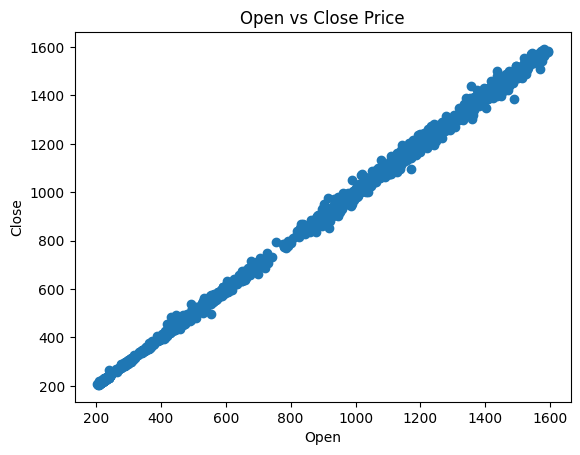

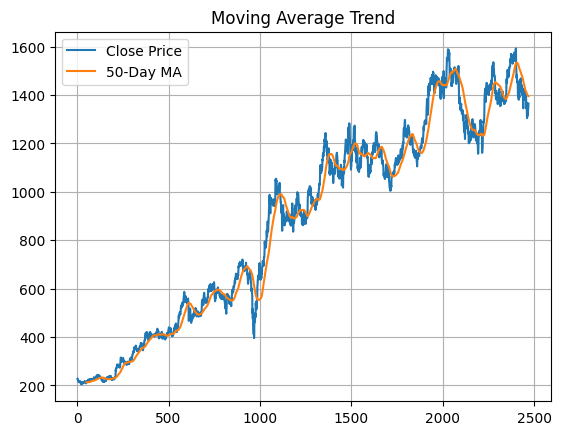

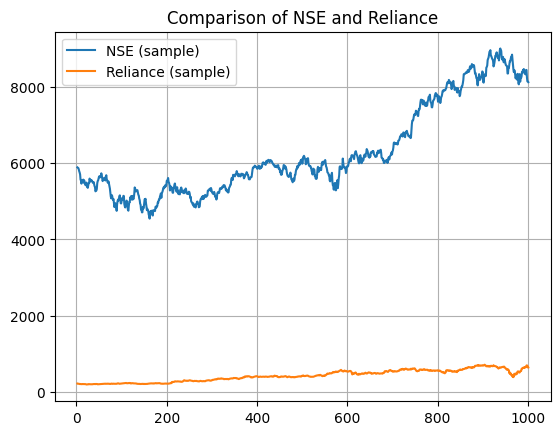

EDA Completed Successfully 🚀


In [1]:
# ===============================
# 📌 IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 📌 LOAD DATA FROM C DRIVE
# ===============================
# Update paths if needed
nse_path = "C:/Stock Prediction Using LSTM/backend/LSTM_Model/data/raw/^NSEI_raw.csv"
reliance_path = "C:/Stock Prediction Using LSTM/backend/LSTM_Model/data/raw/RELIANCE.NS_raw.csv"

nse = pd.read_csv(nse_path)
rel = pd.read_csv(reliance_path)

# ===============================
# 📌 DATA CLEANING FUNCTION
# ===============================
def clean_data(df):
    # Remove header row issue (your dataset has 'Ticker' inside)
    df = df[df['Price'] != 'Ticker']
    
    # Convert columns to numeric
    cols = ['Close', 'High', 'Low', 'Open', 'Volume']
    for col in cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Drop missing values
    df = df.dropna()
    
    return df

nse = clean_data(nse)
rel = clean_data(rel)

# ===============================
# 📌 BASIC INFO
# ===============================
print("NSE DATA SHAPE:", nse.shape)
print("RELIANCE DATA SHAPE:", rel.shape)

# ===============================
# 📌 1. LINE PLOT (CLOSE PRICE TREND)
# ===============================
plt.figure()
plt.plot(nse['Close'], label='NSE Index')
plt.plot(rel['Close'], label='Reliance')
plt.title("Stock Price Trend (Close Price)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

# ===============================
# 📌 2. HIGH vs LOW PRICE RANGE
# ===============================
plt.figure()
plt.plot(nse['High'], label='NSE High')
plt.plot(nse['Low'], label='NSE Low')
plt.title("NSE High vs Low Price")
plt.legend()
plt.grid()
plt.show()

# ===============================
# 📌 3. VOLUME ANALYSIS
# ===============================
plt.figure()
plt.plot(rel['Volume'], label='Reliance Volume')
plt.title("Reliance Trading Volume")
plt.xlabel("Time")
plt.ylabel("Volume")
plt.legend()
plt.grid()
plt.show()

# ===============================
# 📌 4. DISTRIBUTION (HISTOGRAM)
# ===============================
plt.figure()
plt.hist(rel['Close'], bins=50)
plt.title("Distribution of Reliance Close Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# ===============================
# 📌 5. CORRELATION HEATMAP (MANUAL)
# ===============================
corr = rel[['Open','High','Low','Close','Volume']].corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap (Reliance)")
plt.show()

# ===============================
# 📌 6. SCATTER PLOT (RELATIONSHIP)
# ===============================
plt.figure()
plt.scatter(rel['Open'], rel['Close'])
plt.title("Open vs Close Price")
plt.xlabel("Open")
plt.ylabel("Close")
plt.show()

# ===============================
# 📌 7. MOVING AVERAGE TREND
# ===============================
rel['MA50'] = rel['Close'].rolling(window=50).mean()

plt.figure()
plt.plot(rel['Close'], label='Close Price')
plt.plot(rel['MA50'], label='50-Day MA')
plt.title("Moving Average Trend")
plt.legend()
plt.grid()
plt.show()

# ===============================
# 📌 8. NSE vs RELIANCE COMPARISON
# ===============================
plt.figure()
plt.plot(nse['Close'][:1000], label='NSE (sample)')
plt.plot(rel['Close'][:1000], label='Reliance (sample)')
plt.title("Comparison of NSE and Reliance")
plt.legend()
plt.grid()
plt.show()

# ===============================
# 📌 DONE
# ===============================
print("EDA Completed Successfully 🚀")